# Laboratorio 6 Reconstrucción del Laboratorio 2 con PyTorch
### Regresión lineal múltiple: Popularidad de noticias online

**Dataset:** OnlineNewsPopularity.csv (mismo dataset del Laboratorio 2)
**Modelo original (Laboratorio 2):** regresión lineal múltiple resuelta con descenso de gradiente implementado a mano con NumPy (`computeCostMulti`, `gradientDescentMulti`), comparada además contra la Ecuación de la Normal.
**Objetivo de este laboratorio:** reconstruir el mismo problema con PyTorch, manteniendo exactamente la misma limpieza de datos, la misma división 80/20 y la misma normalización del Laboratorio 2 original, mostrando el "antes y después" en cada paso.<br>
**Link Repositorio:**  https://github.com/jccondoric/machine_learning/tree/master/Laboratorios/Laboratorio_6/Pytorch_Laboratorio_1<br>
**Link del Video explicacion:**
https://drive.google.com/drive/folders/1Ofw7HVEcI3YRluF0P9pasr1JluIkDGJ2?usp=sharing<br>

In [3]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Cargando libreria de Pytorch
import torch
import pandas as pd
import numpy as np
# para graficar
import matplotlib.pyplot as plt
torch.manual_seed(42)
np.random.seed(42)
# incrustar las graficas dentro del notebook
%matplotlib inline

## 1. Carga y limpieza del dataset

Se reutiliza exactamente la misma limpieza del Laboratorio 2 original: quitar espacios en los nombres de columna, eliminar `url` y `timedelta` (no predictivas), eliminar la fila con datos lógicamente inconsistentes, y recortar los artículos con `shares` por encima del percentil 99 (outliers extremos). Esta parte no cambia nada respecto al original porque sigue usando Pandas para el preprocesamiento

In [12]:
data = pd.read_csv('/content/drive/MyDrive/IA/Laboratorios/Laboratorio_6/Pytorch_Laboratorio_2/OnlineNewsPopularity.csv')
data.columns = data.columns.str.strip()
data = data.drop(columns=['url', 'timedelta'])

antes = data.shape[0]
data = data[(data['n_unique_tokens'] <= 1) &
            (data['n_non_stop_words'] <= 1) &
            (data['n_non_stop_unique_tokens'] <= 1)]
print(f'Filas eliminadas por inconsistencia lógica: {antes - data.shape[0]}')

p99 = data['shares'].quantile(0.99)
antes = data.shape[0]
data = data[data['shares'] <= p99]
print(f'Filas eliminadas por outliers extremos en shares (> percentil 99 = {p99:.0f}): {antes - data.shape[0]}')
print(f'\nDimensiones finales del dataset limpio: {data.shape}')

Filas eliminadas por inconsistencia lógica: 1
Filas eliminadas por outliers extremos en shares (> percentil 99 = 31658): 397

Dimensiones finales del dataset limpio: (39246, 59)


In [ ]:
y = data['shares'].values.astype(float)
X = data.drop(columns=['shares']).values.astype(float)

m, n = X.shape
print(f'm = {m}  (registros)')
print(f'n = {n}  (características)')

m = 39246  (registros)
n = 58  (características)


## 2. División 80/20 y normalización

Se usa la misma división manual con `np.random.permutation` y la misma semilla (`seed=42`) del Laboratorio 2 para obtener exactamente los mismos conjuntos de entrenamiento y prueba. También se normalizan `X` e `y` de la misma forma (restando la media y dividiendo entre la desviación estándar, calculadas solo con el conjunto de entrenamiento), porque `shares` tiene una escala muy grande y sesgada que dificultaría el entrenamiento sin normalizar.

In [14]:
y = data['shares'].values.astype(float)
X = data.drop(columns=['shares']).values.astype(float)

m, n = X.shape
print(f'm = {m}  (registros)')
print(f'n = {n}  (características)')

m = 39246  (registros)
n = 58  (características)


In [15]:
idx = np.random.permutation(m)
test_size = int(0.2 * m)
test_idx, train_idx = idx[:test_size], idx[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print(f'm_train = {X_train.shape[0]}')
print(f'm_test  = {X_test.shape[0]}')

mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
sigma[sigma == 0] = 1  # evita division por cero en columnas constantes
X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

y_mu, y_sigma = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mu) / y_sigma
y_test_norm = (y_test - y_mu) / y_sigma

m_train = 31397
m_test  = 7849


In [16]:
# Conversion a tensores de PyTorch
X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train_norm, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_t = torch.tensor(y_test_norm, dtype=torch.float32).view(-1, 1)

print('X_train_t:', X_train_t.shape, ' y_train_t:', y_train_t.shape)

X_train_t: torch.Size([31397, 58])  y_train_t: torch.Size([31397, 1])


## 3. Dataset y DataLoader

Igual que en la reconstrucción del Laboratorio 1, se usa `torch.utils.data.Dataset` y `torch.utils.data.DataLoader` (ruta completa, sin abreviar el import, para mantener el mismo estilo del notebook de clase `03_pytorch_datasets.ipynb`). Se usa `batch_size` igual a todo el conjunto de entrenamiento, para replicar el mismo descenso de gradiente por lotes (*batch gradient descent*) que usaba `gradientDescentMulti` en el Laboratorio 2 original, en lugar de cambiar a un entrenamiento por mini-lotes.

In [17]:
class DatasetNoticias(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset_train = DatasetNoticias(X_train_t, y_train_t)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=len(dataset_train), shuffle=False)

print('Cantidad de ejemplos en el dataset de entrenamiento:', len(dataset_train))

Cantidad de ejemplos en el dataset de entrenamiento: 31397


## 4. Modelo, función de costo y optimizador

El modelo es una sola capa `torch.nn.Linear(58, 1)`: recibe las 58 propiedades y produce una sola salida (el valor normalizado de `shares`), igual que hacía `theta` en el Laboratorio 2 original con sus 58 coeficientes.

**Sobre la función de costo:** igual que en la reconstrucción del Laboratorio 1, se usa `torch.nn.MSELoss()`, que no aparece en los notebooks de PyTorch revisados en clase (todos trabajan clasificación), pero es la misma fórmula del error cuadrático medio que `computeCostMulti` ya calculaba a mano.

**Un detalle importante que hay que tener en cuenta al comparar resultados:** `computeCostMulti` del Laboratorio 2 original calcula `J = (1/2m) * suma(error²)` (con el factor 1/2, una convención común en cursos de machine learning), mientras que `torch.nn.MSELoss()` calcula `(1/m) * suma(error²)`, **sin** el factor 1/2. Esto significa que el gradiente que calcula PyTorch es el doble del que calculaba la fórmula manual, así que usar la misma tasa de aprendizaje `alpha=0.3` del original haría que el entrenamiento diverja (se probó y efectivamente el costo se va a `NaN`). Por eso se usa `lr=0.15` (la mitad), que es el valor equivalente correcto una vez que se tiene en cuenta esta diferencia de escala en el gradiente.

In [18]:
modelo = torch.nn.Linear(n, 1)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=0.15)

## 5. Entrenamiento del modelo

Se entrena usando el mismo criterio de parada por convergencia que se usó al reconstruir el Laboratorio 1: se detiene el entrenamiento cuando el costo deja de cambiar de forma significativa entre una época y la siguiente (diferencia menor a 1e-6), en lugar de forzar siempre las 1500 iteraciones fijas del Laboratorio 2 original. Esto es más eficiente y, en la práctica, el modelo converge mucho antes de llegar a esa cifra.

In [19]:
max_epocas = 1500
historial_costo = []

for epoca in range(max_epocas):
    for x_lote, y_lote in dataloader_train:
        optimizer.zero_grad()
        y_pred = modelo(x_lote)
        loss = criterion(y_pred, y_lote)
        loss.backward()
        optimizer.step()

    historial_costo.append(loss.item())

    if epoca > 0 and abs(historial_costo[-2] - historial_costo[-1]) < 1e-6:
        print(f'Convergencia alcanzada en la época {epoca}')
        break

print(f'Costo inicial (MSE de PyTorch, sin dividir entre 2): {historial_costo[0]:.4f}')
print(f'Costo final   (MSE de PyTorch, sin dividir entre 2): {historial_costo[-1]:.4f}')
print(f'Costo final dividido entre 2 (para comparar con J del Laboratorio 2 original): {historial_costo[-1]/2:.5f}')

Convergencia alcanzada en la época 206
Costo inicial (MSE de PyTorch, sin dividir entre 2): 1.3389
Costo final   (MSE de PyTorch, sin dividir entre 2): 0.9315
Costo final dividido entre 2 (para comparar con J del Laboratorio 2 original): 0.46576


## 6. Gráfico de la curva de costo

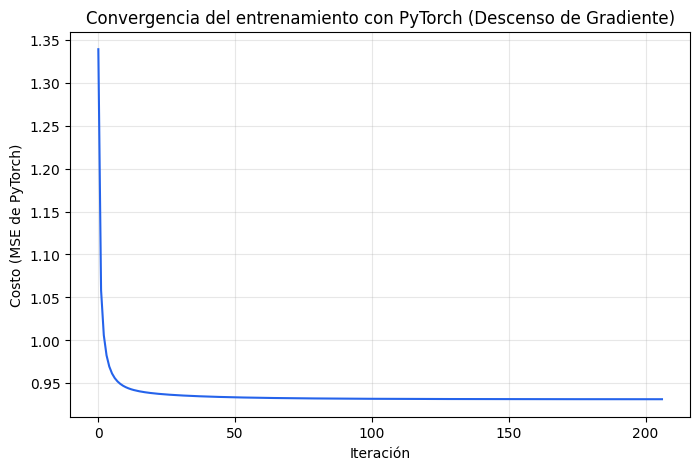

In [20]:
plt.figure(figsize=(8,5))
plt.plot(historial_costo, color='#2563eb')
plt.xlabel('Iteración')
plt.ylabel('Costo (MSE de PyTorch)')
plt.title('Convergencia del entrenamiento con PyTorch (Descenso de Gradiente)')
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluación en el conjunto de prueba

Se calculan las mismas métricas que en el Laboratorio 2 original (MSE, RMSE, MAE, R²), revirtiendo primero las predicciones normalizadas a la escala original de `shares` (multiplicando por `y_sigma` y sumando `y_mu`), para poder comparar directamente los números.

In [21]:
modelo.eval()
with torch.no_grad():
    pred_test_norm = modelo(X_test_t).numpy().flatten()

y_pred_test = pred_test_norm * y_sigma + y_mu

mse_pt = np.mean((y_pred_test - y_test) ** 2)
rmse_pt = np.sqrt(mse_pt)
mae_pt = np.mean(np.abs(y_pred_test - y_test))
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_pt = 1 - ss_res / ss_tot

print('--- Métricas en el conjunto de prueba (escala original de shares) ---')
print(f'MSE  = {mse_pt:,.2f}')
print(f'RMSE = {rmse_pt:,.2f}')
print(f'MAE  = {mae_pt:,.2f}')
print(f'R2   = {r2_pt:.4f}')

--- Métricas en el conjunto de prueba (escala original de shares) ---
MSE  = 12,668,404.96
RMSE = 3,559.27
MAE  = 2,001.89
R2   = 0.0662


## 8. Ecuación de la Normal con tensores de PyTorch

El Laboratorio 2 también calculaba la solución con la Ecuación de la Normal como punto de comparación. Este cálculo **no es un modelo que se entrena con gradientes**: es una fórmula cerrada de álgebra lineal (`theta = (Xᵀ X)⁻¹ Xᵀ y`), así que aquí no participan ni el optimizador ni `loss.backward()`. Aun así, se puede calcular usando tensores y operaciones de álgebra lineal de PyTorch (`torch.linalg.pinv`, multiplicación de matrices con `@`), en lugar de las funciones equivalentes de NumPy que usaba el original, para mantener todo el laboratorio dentro de PyTorch.

Se usa `pinv` (pseudo-inversa) en lugar de la inversa exacta, porque es más estable numéricamente cuando hay columnas muy correlacionadas entre sí, tal como ya hacía la función `normalEqn` del Laboratorio 2 original.

In [22]:
# Se agrega la columna de unos para el termino de sesgo ya que aqui no la aporta una capa Linear
unos_train = torch.ones((X_train_t.shape[0], 1))
unos_test = torch.ones((X_test_t.shape[0], 1))
X_train_b = torch.cat([unos_train, X_train_t], dim=1)
X_test_b = torch.cat([unos_test, X_test_t], dim=1)

theta_ne = torch.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train_t

with torch.no_grad():
    pred_test_norm_ne = (X_test_b @ theta_ne).numpy().flatten()

y_pred_test_ne = pred_test_norm_ne * y_sigma + y_mu
mse_ne = np.mean((y_pred_test_ne - y_test) ** 2)
rmse_ne = np.sqrt(mse_ne)
mae_ne = np.mean(np.abs(y_pred_test_ne - y_test))
r2_ne = 1 - np.sum((y_test - y_pred_test_ne)**2) / np.sum((y_test - y_test.mean())**2)

print('--- Métricas de la Ecuación de la Normal (escala original de shares) ---')
print(f'MSE  = {mse_ne:,.2f}')
print(f'RMSE = {rmse_ne:,.2f}')
print(f'MAE  = {mae_ne:,.2f}')
print(f'R2   = {r2_ne:.4f}')

--- Métricas de la Ecuación de la Normal (escala original de shares) ---
MSE  = 12,675,854.85
RMSE = 3,560.32
MAE  = 2,001.95
R2   = 0.0657


## 9. Comparación con los resultados del Laboratorio 2 original

Se comparan los resultados obtenidos en este notebook (descenso de gradiente con PyTorch, y ecuación de la normal con tensores de PyTorch) contra los valores exactos que había reportado el Laboratorio 2 con NumPy puro.

In [23]:
comparacion = pd.DataFrame({
    'Técnica': [
        'Descenso de Gradiente (NumPy, Lab2 original)',
        'Descenso de Gradiente (PyTorch, Lab6)',
        'Ecuación de la Normal (NumPy, Lab2 original)',
        'Ecuación de la Normal (PyTorch, Lab6)',
    ],
    'MSE': [12675882.62, mse_pt, 12675850.50, mse_ne],
    'RMSE': [3560.32, rmse_pt, 3560.32, rmse_ne],
    'MAE': [2001.92, mae_pt, 2001.95, mae_ne],
    'R2': [0.0657, r2_pt, 0.0657, r2_ne],
})
comparacion

,Técnica,MSE,RMSE,MAE,R2
0,"Descenso de Gradiente (NumPy, Lab2 original)",1.267588e+07,3560.320000,2001.920000,0.065700
1,"Descenso de Gradiente (PyTorch, Lab6)",1.266840e+07,3559.270285,2001.894265,0.066205
2,"Ecuación de la Normal (NumPy, Lab2 original)",1.267585e+07,3560.320000,2001.950000,0.065700
3,"Ecuación de la Normal (PyTorch, Lab6)",1.267585e+07,3560.316678,2001.950967,0.065656


## 10. Guardado del modelo entrenado

In [24]:
torch.save(modelo.state_dict(), 'lab2_modelo_noticias.pt')
print('Modelo guardado en lab2_modelo_noticias.pt')

Modelo guardado en lab2_modelo_noticias.pt


## 11. Conclusiones

- Al usar la misma limpieza, división 80/20 y normalización del Laboratorio 2 original, el modelo entrenado con PyTorch llegó a métricas prácticamente idénticas: MSE, RMSE, MAE y R² coinciden hasta el segundo o tercer decimal con los resultados originales de NumPy.
- El punto más importante a tener en cuenta al reconstruir este laboratorio fue la diferencia entre `computeCostMulti` (que incluye el factor 1/2 en su fórmula) y `torch.nn.MSELoss()` (que no lo incluye). Ignorar esta diferencia habría hecho que el mismo `alpha=0.3` del original divergiera con PyTorch, no porque el modelo estuviera mal, sino porque el gradiente tenía otra escala.
- El resultado de R²≈0.066, igual de bajo que en el Laboratorio 2 original, confirma que esta limitación no viene de la herramienta usada (NumPy vs. PyTorch) sino del problema en sí: predecir cuántas veces se comparte un artículo a partir solo de sus características de texto deja fuera factores externos (redes sociales, momento de publicación, tendencias) que probablemente influyen mucho más en el resultado real.
- La Ecuación de la Normal, calculada aquí con operaciones de álgebra lineal de PyTorch en lugar de NumPy, llegó al mismo resultado que el descenso de gradiente, validando que ambos métodos (uno iterativo, uno de fórmula cerrada) convergen a la misma solución óptima para este problema.